In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D
from scdepth.bindings import Downsampler
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import scdepth.fn as fn, scdepth.fit as fit, scdepth.pl as pl, scdepth.filt as filt
from scipy import stats
import os
import subprocess

In [2]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
tmap = {(c.group, c.subgroup):c for c in cdf.itertuples()}
#cdf = cdf[cdf['group'].str.contains('visium') | cdf['group'].str.contains('PBMC')].copy()
#adf = adf[adf['group'].str.contains('visium') | adf['group'].str.contains('PBMC')].copy()
cdf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')

In [3]:
summaries = []
samples = set()

vdfs = []
pdfs = []

mchecks = []

for i, c in cdf.iterrows():
    f1 = f'../{c["dataset"]}/{c["sample"]}/scdepth_limit_summary.txt'
    f2 = f'../{c["dataset"]}/{c["sample"]}/scdepth_preseq_summary.txt'
    f3 = f'../{c["dataset"]}/{c["sample"]}/scdepth_fit_baseline.txt'

    bdf = pd.read_csv(f3, sep='\t').iloc[0]


    if not os.path.isfile(f1):
        continue

    cc = adf[(adf['group'] == c['group']) & (adf['subgroup'] == c['subgroup'])].iloc[0]

                        
    d = pd.read_csv(f1, sep='\t')
    d2 = pd.read_csv(f2, sep='\t')
    
    d = d.merge(d2[['curve','limit','preseq_mae','preseq_L', 'preseq_L_defect']], left_on = ['curve','limit'], right_on = ['curve', 'limit'])
    d['color'] = cc['group_color']


    
    if bdf.full_saturation > 80:  
        mchecks.append((c['sample'], cc, bdf.full_saturation, bdf.full_molecules, d))
    dd = d                        
    if 'visium' in cc['group']:
        vdfs.append(dd[['sample','limit','ztnb_ks', 'ztnb_rhat', 'nb_lib_err', 'nb_lib_L', 'preseq_mae','preseq_L', 'preseq_L_defect', 'color']].copy())
    else:
        pdfs.append(dd[['sample','limit','ztnb_ks', 'ztnb_rhat', 'nb_lib_err', 'nb_lib_L', 'preseq_mae','preseq_L', 'preseq_L_defect', 'color']].copy())
    summaries.append((c, dd))
vdfs = pd.concat(vdfs)
pdfs = pd.concat(pdfs)

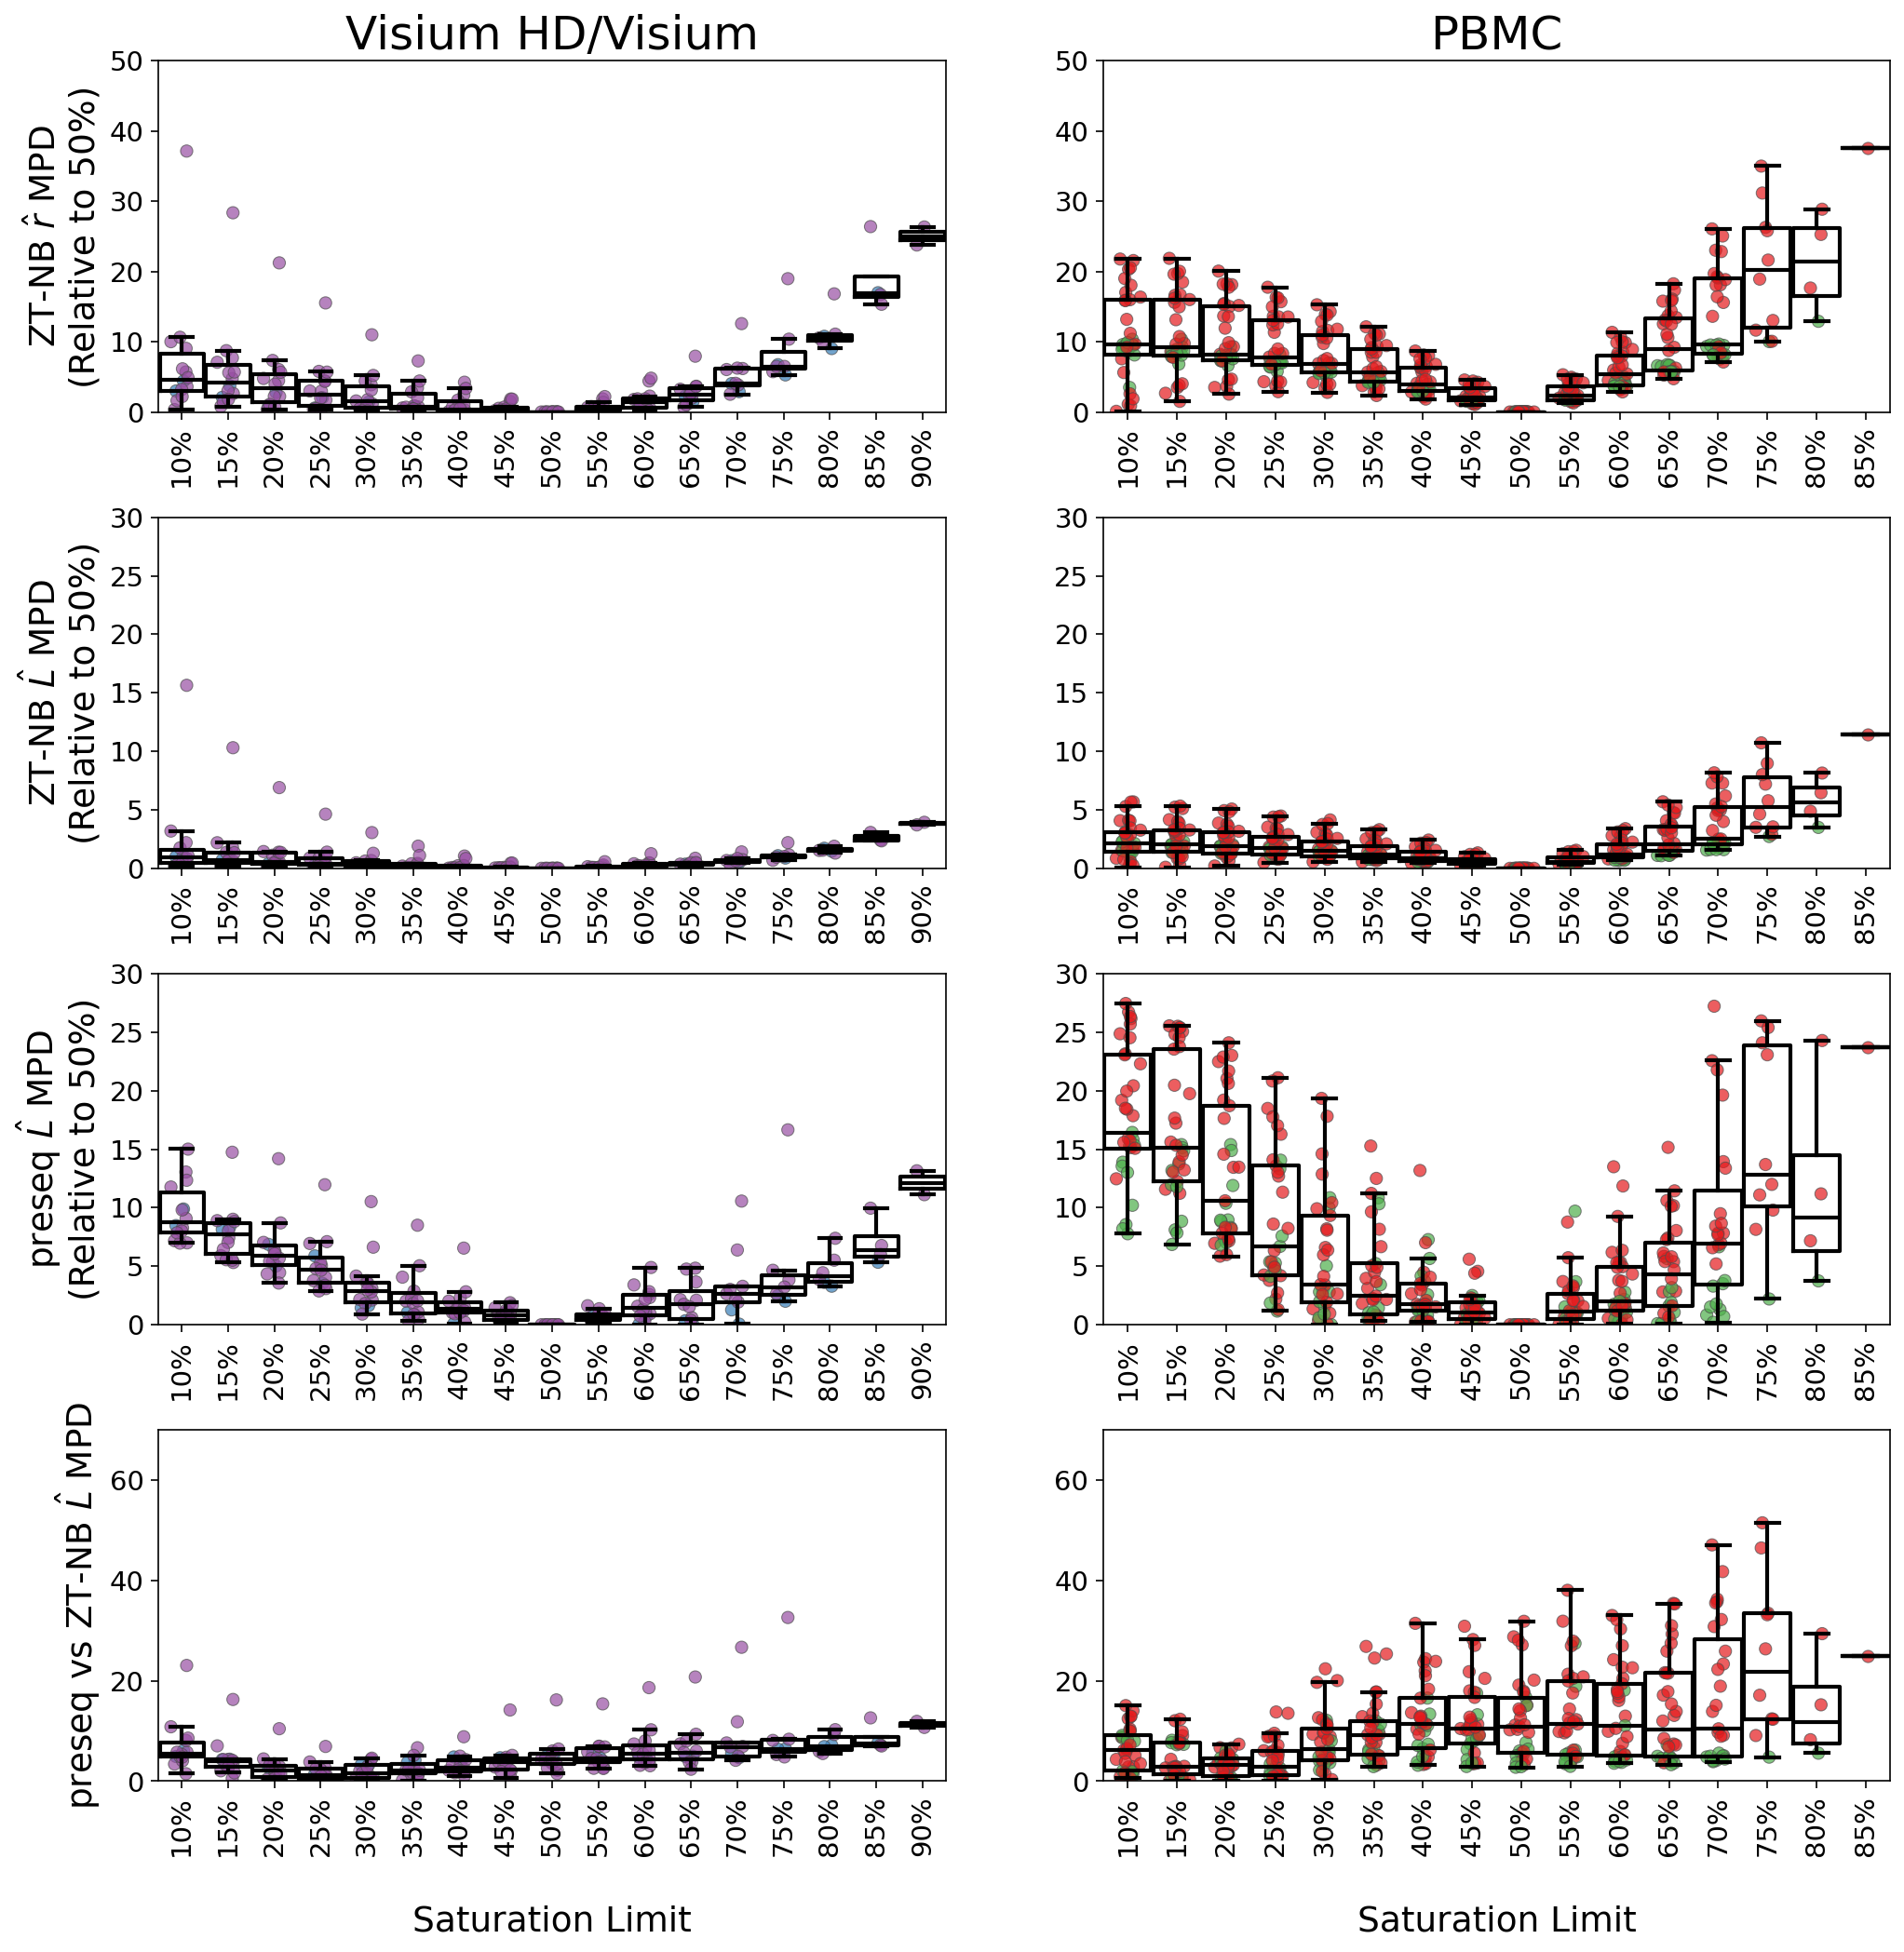

In [4]:
fig, axs = pl.figax(4, 2, w=8, h=4)
fig.subplots_adjust(hspace=0.3)
for dd, rx in zip((vdfs, pdfs), axs.T):

    nb_L_mpd = {}
    nb_r_mpd = {}
    pr_L_mpd = {}
    pr_vs_nb = {}
    colors = {}
    
    lims = {}
    for s, sd in dd.groupby('sample'):
        cc = cdf[cdf['sample'] == s].iloc[0]

        gmean = sd[['limit','ztnb_rhat', 'nb_lib_L', 'preseq_L']].groupby('limit').mean()
        gmean['limit'] = gmean.index
        gmean.reset_index(inplace=True, drop=True)
        cidx = (gmean.limit - 50).abs().idxmin()
        bL = gmean.loc[cidx, 'nb_lib_L']
        pL = gmean.loc[cidx, 'preseq_L']
        bR = gmean.loc[cidx, 'ztnb_rhat']

        for i, t in enumerate(gmean.itertuples()):
            lims[i] = t.limit
            colors.setdefault(i, []).append(cc.group_color)
            nb_L_mpd.setdefault(i, []).append(100 * np.abs(t.nb_lib_L -  bL)/bL)
            pr_L_mpd.setdefault(i, []).append(100 * np.abs(t.preseq_L - pL) / pL)
            pr_vs_nb.setdefault(i, []).append(100 * np.abs(t.preseq_L - t.nb_lib_L) / t.nb_lib_L)
            nb_r_mpd.setdefault(i, []).append(100 * np.abs(t.ztnb_rhat - bR) / bR)
    xt = []
    xl = []
    for i, l in sorted(lims.items()):
        xt.append(i)
        xl.append(f'{l:.0f}%')
        pl.jitter_box(rx[0], i, nb_r_mpd[i], s=40, c=colors[i], alpha=0.7, edgecolor='0.3', lw=0.5, blw=2, mlw=2, wlw=2, plw=2)
        pl.jitter_box(rx[1], i, nb_L_mpd[i], s=40, c=colors[i], alpha=0.7, edgecolor='0.3', lw=0.5, blw=2, mlw=2, wlw=2, plw=2)
        pl.jitter_box(rx[2], i, pr_L_mpd[i], s=40, c=colors[i], alpha=0.7, edgecolor='0.3', lw=0.5, blw=2, mlw=2, wlw=2, plw=2)
        pl.jitter_box(rx[3], i, pr_vs_nb[i], s=40, c=colors[i], alpha=0.7, edgecolor='0.3', lw=0.5, blw=2, mlw=2, wlw=2, plw=2)
    for ax in rx:
        ax.set_xticks(xt)
        ax.set_xticklabels(xl, rotation=90)
    rx[-1].set_xlabel('Saturation Limit', fontsize=18, labelpad=25)
lims = [50, 20, 40, 50]
for rx, l in zip(axs.T, lims):
    for ax in rx:
        ax.set_ylim(0, l)
        ax.tick_params(axis='both', which='both', length=4)
        ax.tick_params(axis='both', which='major', labelsize=14)

lims = [50, 30, 30, 70]
for r,l in zip(axs, lims):
    for ax in r:
        ax.set_ylim(0, l)

axs[0,0].set_title('Visium HD/Visium', fontsize=24)
axs[0,1].set_title('PBMC', fontsize=24)

axs[0,0].set_ylabel('ZT-NB $\\hat{r}$ MPD\n(Relative to 50%)', fontsize=18)
axs[1,0].set_ylabel('ZT-NB $\\hat{L}$ MPD\n(Relative to 50%)', fontsize=18)
axs[2,0].set_ylabel('preseq $\\hat{L}$ MPD\n(Relative to 50%)', fontsize=18)
axs[3,0].set_ylabel('preseq vs ZT-NB $\\hat{L}$ MPD', fontsize=18)


fig.savefig('../Figures/Figure S3 Parameter Drift.svg', bbox_inches='tight')